# Libraries & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('/kaggle/input/datasets/aliyasaly1231/healthy-diet-and-calorie-intake/healthy_diet_calorie_intake.csv')

df.head()

,Person_ID,Age,Gender,Height_cm,Weight_kg,BMI,Activity_Level,Daily_Calorie_Requirement,Daily_Calorie_Consumed,Protein_Intake_g,Carbohydrate_Intake_g,Fat_Intake_g,Water_Intake_Liters,Diet_Type,Health_Status
0,P0001,50,Male,176.4,74.8,24.0,Very Active,2852,2625,183.0,16.9,202.8,3.3,Keto,Healthy
1,P0002,18,Female,167.6,75.5,26.9,Sedentary,1904,2044,90.1,306.5,50.8,1.9,Vegan,Overweight
2,P0003,68,Female,161.9,87.2,33.3,Lightly Active,2009,2540,222.7,281.3,58.2,2.4,High Protein,Obese
3,P0004,22,Female,169.3,66.9,23.3,Moderately Active,2318,2096,69.5,299.8,68.7,2.9,Balanced,Healthy
4,P0005,30,Male,179.1,75.3,23.5,Sedentary,2144,1937,32.9,285.6,73.7,2.2,Balanced,Healthy


In [3]:

print(f"Dataset shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\n Column names  :\n  {', '.join(df.columns.tolist())}")


Dataset shape : 6,000 rows × 15 columns

 Column names  :
  Person_ID, Age, Gender, Height_cm, Weight_kg, BMI, Activity_Level, Daily_Calorie_Requirement, Daily_Calorie_Consumed, Protein_Intake_g, Carbohydrate_Intake_g, Fat_Intake_g, Water_Intake_Liters, Diet_Type, Health_Status


In [4]:
info_df = pd.DataFrame({
    'dtype'   : df.dtypes,
    'non_null': df.notnull().sum(),
    'missing' : df.isnull().sum(),
    'unique'  : df.nunique()
})
info_df


,dtype,non_null,missing,unique
Person_ID,object,6000,0,6000
Age,int64,6000,0,63
Gender,object,6000,0,3
Height_cm,float64,6000,0,460
Weight_kg,float64,6000,0,633
BMI,float64,6000,0,255
Activity_Level,object,6000,0,5
Daily_Calorie_Requirement,int64,6000,0,1855
Daily_Calorie_Consumed,int64,6000,0,2218
Protein_Intake_g,float64,6000,0,2098


In [5]:
df.to_csv(
    "/kaggle/working/processed_dataset.csv",
    index=False
)

print("Output file created successfully!")
os.listdir("/kaggle/working")

Output file created successfully!


['__notebook__.ipynb', 'processed_dataset.csv']

# EDA 

In [6]:
num_cols = df.select_dtypes(include='number').columns.drop('Person_ID', errors='ignore').tolist()
cat_cols = df.select_dtypes(include='object').columns.drop('Person_ID', errors='ignore').tolist()

print(f" Numerical columns  ({len(num_cols)}) : {num_cols}")
print(f" Categorical columns ({len(cat_cols)}) : {cat_cols}")

 Numerical columns  (10) : ['Age', 'Height_cm', 'Weight_kg', 'BMI', 'Daily_Calorie_Requirement', 'Daily_Calorie_Consumed', 'Protein_Intake_g', 'Carbohydrate_Intake_g', 'Fat_Intake_g', 'Water_Intake_Liters']
 Categorical columns (4) : ['Gender', 'Activity_Level', 'Diet_Type', 'Health_Status']


In [7]:
df[num_cols].describe().round(2)


,Age,Height_cm,Weight_kg,BMI,Daily_Calorie_Requirement,Daily_Calorie_Consumed,Protein_Intake_g,Carbohydrate_Intake_g,Fat_Intake_g,Water_Intake_Liters
count,6000.00,6000.00,6000.00,6000.00,6000.00,6000.00,6000.00,6000.00,6000.00,6000.00
mean,48.82,168.59,74.07,26.09,2286.22,2490.52,123.77,288.04,93.70,2.73
std,18.14,9.16,12.42,4.16,469.54,602.28,62.00,123.91,43.95,0.68
min,18.00,145.00,40.00,12.90,1223.00,1000.00,17.40,-23.60,23.20,1.50
25%,33.00,161.70,65.50,23.30,1941.00,2057.00,78.80,229.10,65.90,2.20
50%,48.00,168.20,74.10,26.00,2232.50,2433.00,108.90,297.15,82.30,2.60
75%,65.00,175.20,82.70,28.90,2581.25,2859.00,155.10,366.12,105.10,3.10
max,80.00,198.60,116.60,44.00,4079.00,5158.00,457.50,729.70,341.70,5.00


In [8]:
for col in cat_cols:
    print(f"\n{col}  ({df[col].nunique()} categories)")
    print(df[col].value_counts().to_string())


Gender  (3 categories)
Gender
Male      2892
Female    2855
Other      253

Activity_Level  (5 categories)
Activity_Level
Lightly Active       1627
Moderately Active    1509
Sedentary            1487
Very Active           970
Athlete               407

Diet_Type  (6 categories)
Diet_Type
Balanced         1536
High Protein     1076
Vegetarian       1055
Mediterranean    1027
Keto              721
Vegan             585

Health_Status  (4 categories)
Health_Status
Overweight     2500
Healthy        2249
Obese          1076
Underweight     175


# Data Composition

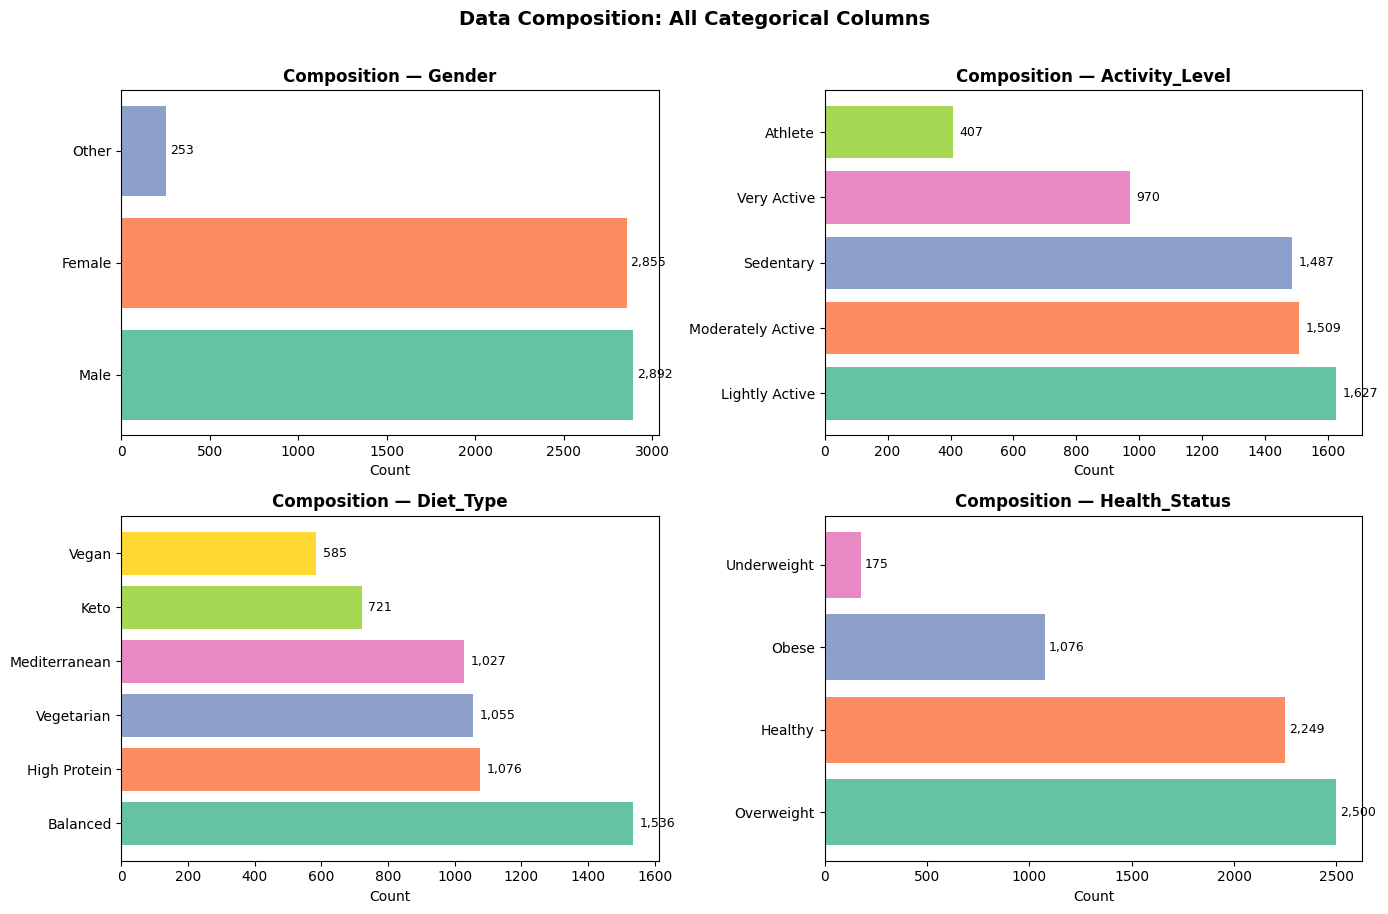

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[i].barh(counts.index, counts.values,
                 color=sns.color_palette('Set2', len(counts)))
    axes[i].set_title(f'Composition — {col}', fontweight='bold')
    axes[i].set_xlabel('Count')
    for bar, val in zip(axes[i].patches, counts.values):
        axes[i].text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
                     f'{val:,}', va='center', fontsize=9)

plt.suptitle('Data Composition: All Categorical Columns', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


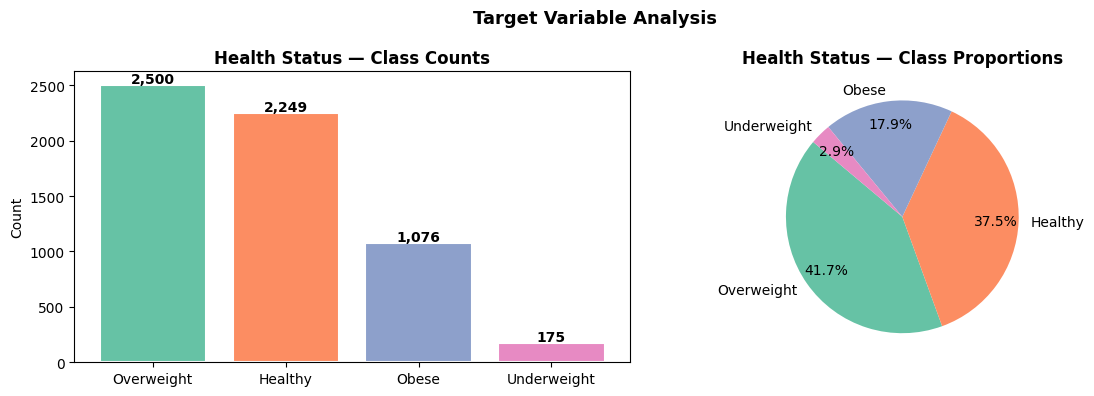


📊 Class balance summary:
  Overweight      2,500  ( 41.7%)  ████████████████████
  Healthy         2,249  ( 37.5%)  ██████████████████
  Obese           1,076  ( 17.9%)  ████████
  Underweight       175  (  2.9%)  █


In [10]:
target_counts = df['Health_Status'].value_counts()
pct           = (target_counts / len(df) * 100).round(1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
ax1.bar(target_counts.index, target_counts.values,
        color=sns.color_palette('Set2', len(target_counts)), edgecolor='white', linewidth=1.5)
ax1.set_title('Health Status — Class Counts', fontweight='bold')
ax1.set_ylabel('Count')
for bar, val in zip(ax1.patches, target_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             f'{val:,}', ha='center', fontweight='bold')

# Pie chart
ax2.pie(target_counts.values, labels=target_counts.index,
        autopct='%1.1f%%', colors=sns.color_palette('Set2', len(target_counts)),
        startangle=140, pctdistance=0.8)
ax2.set_title('Health Status — Class Proportions', fontweight='bold')

plt.suptitle('Target Variable Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📊 Class balance summary:")
for label, cnt, p in zip(target_counts.index, target_counts.values, pct.values):
    bar = '█' * int(p / 2)
    print(f"  {label:<15} {cnt:>5,}  ({p:>5}%)  {bar}")

# Data Distribution

In [11]:
data = pd.DataFrame({
    'skewness' : df[num_cols].skew().round(3),
    'kurtosis' : df[num_cols].kurt().round(3)
}).sort_values('skewness', ascending=False)

print("Skewness > |0.5| suggests non-symmetrical distribution")
print("Kurtosis > 3 suggests heavy tails (more outliers)")
print()
data

Skewness > |0.5| suggests non-symmetrical distribution
Kurtosis > 3 suggests heavy tails (more outliers)



,skewness,kurtosis
Fat_Intake_g,1.888,4.219
Protein_Intake_g,1.114,1.126
Water_Intake_Liters,0.762,0.124
Daily_Calorie_Requirement,0.525,-0.041
Daily_Calorie_Consumed,0.507,0.275
BMI,0.155,0.084
Height_cm,0.134,-0.467
Age,0.042,-1.204
Weight_kg,-0.003,-0.257
Carbohydrate_Intake_g,-0.352,0.192


# Data Relationships

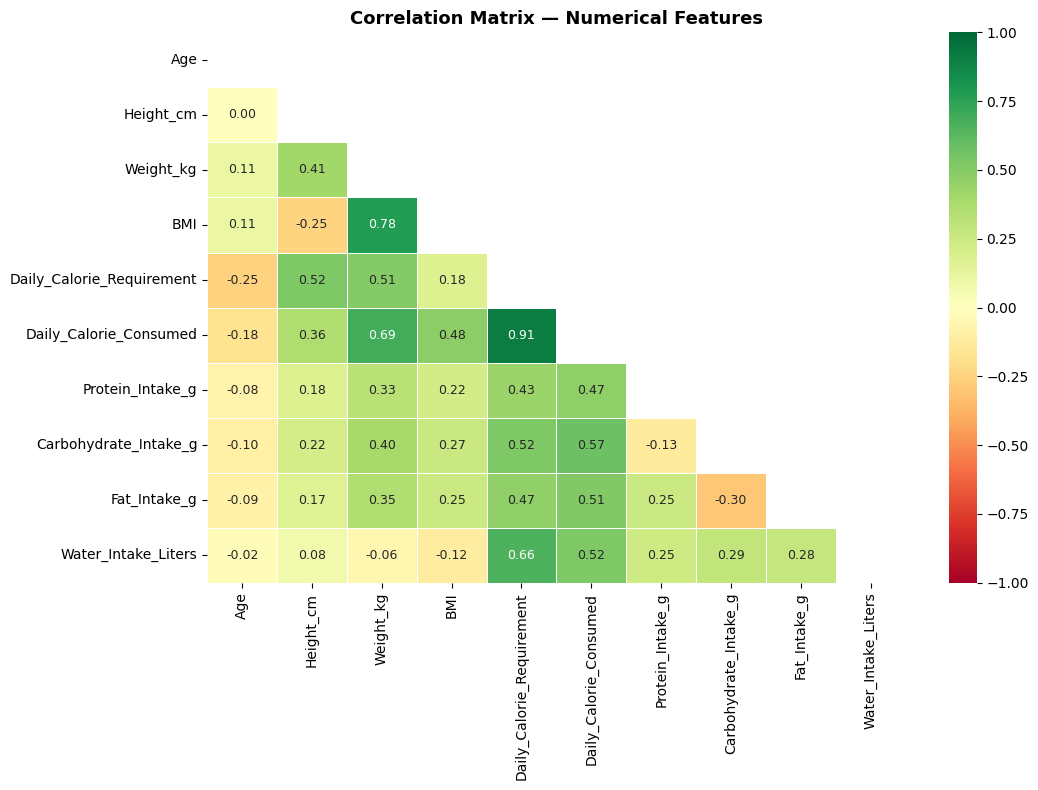

In [12]:
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))   # hide upper triangle
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            annot_kws={'size': 9}, ax=ax)
ax.set_title('Correlation Matrix — Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


# Data Comparison

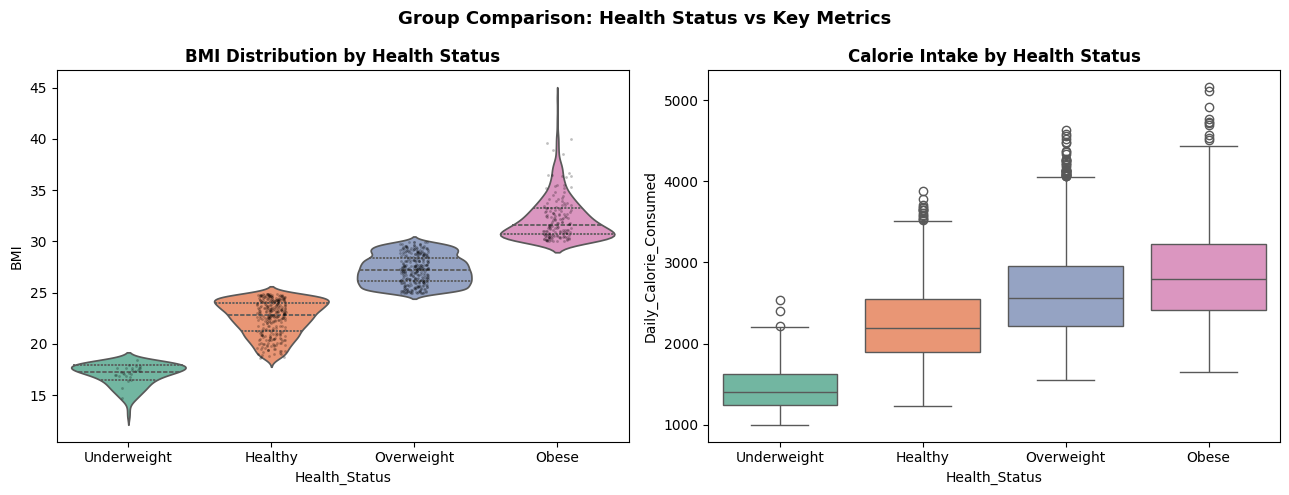

In [13]:
order = ['Underweight', 'Healthy', 'Overweight', 'Obese']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Violin
sns.violinplot(data=df, x='Health_Status', y='BMI', order=order,
               palette='Set2', inner='quartile', ax=axes[0])
axes[0].set_title('BMI Distribution by Health Status', fontweight='bold')

# Strip (raw data overlay)
sns.stripplot(data=df.sample(800, random_state=42),
              x='Health_Status', y='BMI', order=order,
              color='black', alpha=0.25, size=2, ax=axes[0])

# Box
sns.boxplot(data=df, x='Health_Status', y='Daily_Calorie_Consumed',
            order=order, palette='Set2', ax=axes[1])
axes[1].set_title('Calorie Intake by Health Status', fontweight='bold')

plt.suptitle('Group Comparison: Health Status vs Key Metrics',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
